# GraphSAGE: sample, aggregate, generalize

Full inline GraphSAGE mean port and original full PPI archive. Three TODOs feed the actual training path. The one-epoch diagnostic and full ten-epoch search are separate experiments.

In [ ]:
# @colab-bootstrap
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy','torch','scikit-learn'])

## Start with retrieval — before reading

Close lesson 82. Write three answers: (1) What could a test node contribute during Cora training even though its label was hidden? (2) Why is the GCN coefficient not an ordinary neighbor mean? (3) Which parameters belong to a node, and which are shared across nodes? Keep your answers; revise them at the end.

**Pause: write your prediction or teach-back before continuing.**

**Today's win:** trace a sampled two-layer GraphSAGE computation, implement its mean aggregator, and demonstrate that training cannot access held-out graphs. The core route takes about 40 minutes; the full experiment is a separate executable lab. This serves our relational mission: new database rows need usable representations before we have labels for them.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 083</p><p><strong>Build on what you know.</strong> <a href="https://avistian.github.io/relational/lessons/0082-gcn.html">Lesson 82</a> performed a full-graph forward pass. GraphSAGE moves attention to a reusable neighborhood function and the dependencies of a root mini-batch. The inductive split must be stated separately from the layer formula.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0084-gat.html">Lesson 84</a> replaces equal neighbor weighting with attention; <a href="https://avistian.github.io/relational/lessons/0089-sampling-at-scale.html">Lesson 89</a> changes the sampling unit from nested neighborhoods to clusters. Both inherit the need to account for support nodes.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>

## Sampling decides the computation you can afford

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">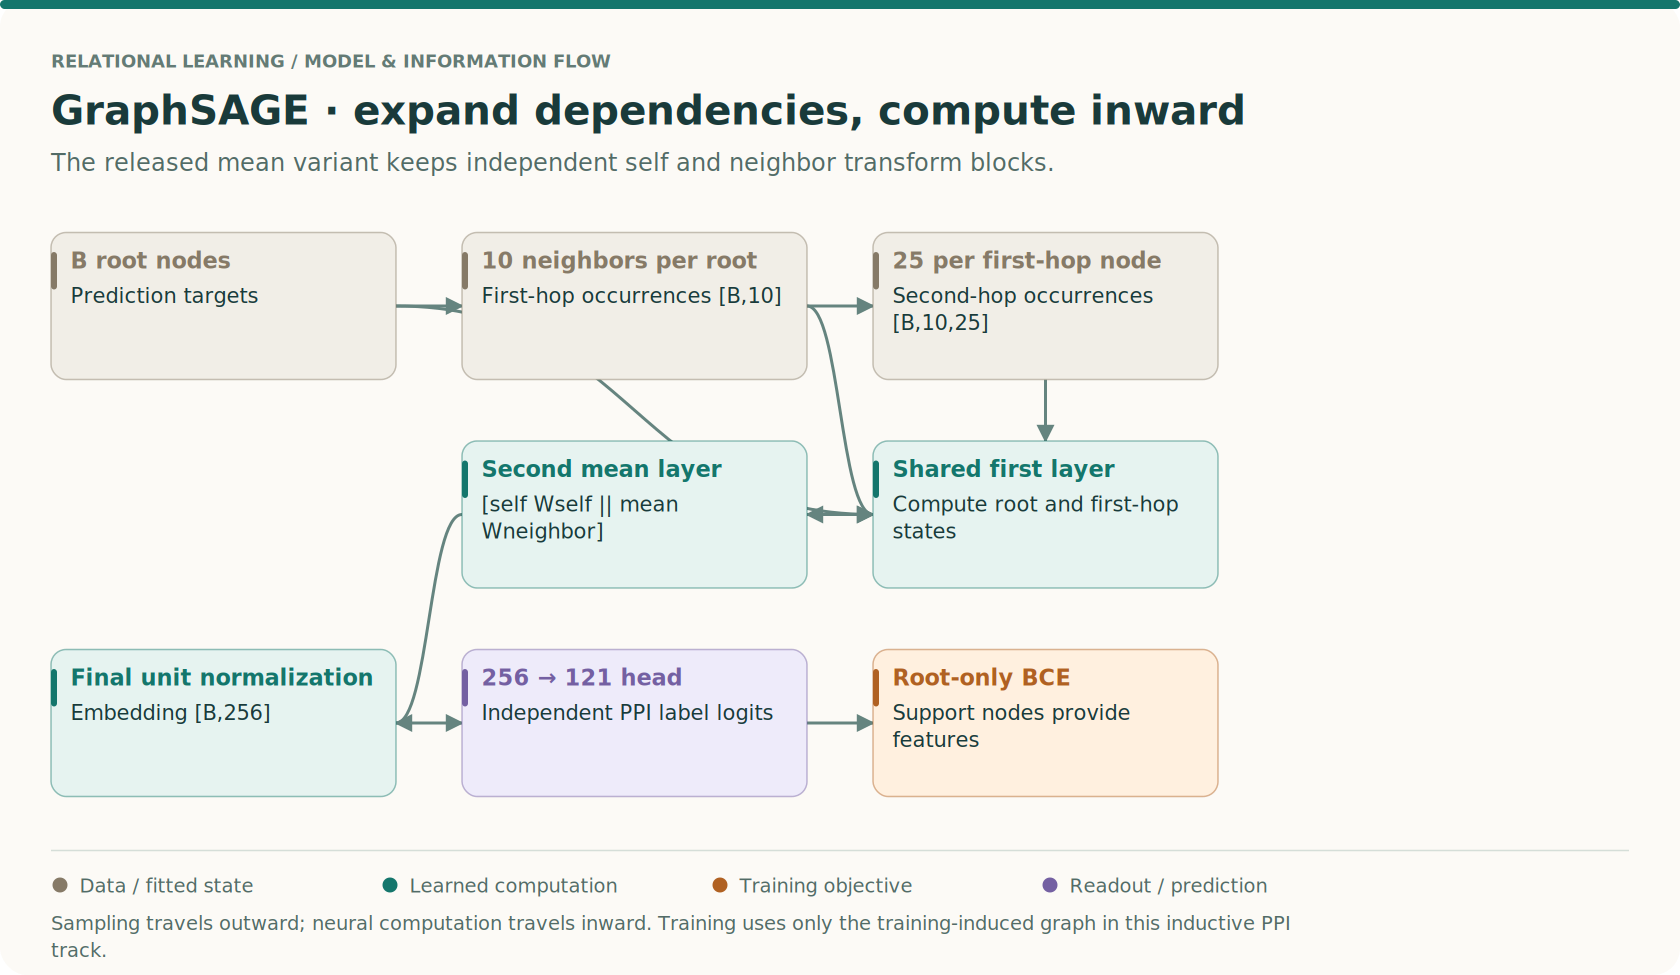</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read pseudocode and release as separate specifications

Read [Hamilton et al. Algorithm 1 and §3.1](https://arxiv.org/html/1706.02216v4), then the pinned mean-aggregator code linked below. The body of this lesson documents differences in concatenation, normalization and sampling order. A modern library class called “SAGE” is not sufficient evidence of historical recipe identity.

### Build one two-layer root computation

1. **Choose roots first.** These are the nodes whose predictions and targets define the mini-batch loss. A support node is present because a root depends on its features; it does not automatically become a supervised example.
2. **Sample outward.** In the released recipe used here, each root has 10 immediate sampled neighbors and each of those has 25 more occurrences. With B=2, the materialized levels contain 2,20 and 500 occurrences. Duplicate node IDs are allowed, so 522 occurrences need not mean 522 unique nodes.
3. **Compute inward.** Use raw second-hop features to construct first-hop states. Also construct the roots' first-layer states with the same first-layer weights. Only then apply the second layer to roots. Skipping a layer for support states changes the function even if final dimensions still match.
4. **Keep the two branches visible.** With root [2,4] and neighbors [1,3],[5,1], the mean is [3,2]. Identity branch transforms yield [2,4,3,2] after concatenation. Adding the branches instead gives [5,6]; it is another architecture with another width and information bottleneck.
5. **Normalize at the documented stage.** The example concatenation has norm √33. Dividing by this produces a unit vector. The released path normalizes at the final embedding; reproducing the paper pseudocode's per-layer normalization instead is an explicit variant.
6. **Score the roots.** For PPI, each root can have multiple positive labels. Use independent label logits and binary cross-entropy, not a class softmax that forces all label probabilities to sum to one.

<details><summary>Predict: an unbiased sampled mean guarantees an unbiased network prediction?</summary><p>No. Even when a sample mean is unbiased under a stated sampling scheme, nonlinear transformations generally satisfy E[f(m)]≠f(E[m]). The fixed capped/padded adjacency table in this release adds another distinction from uniform sampling over the original neighbor list.</p></details>

**Your intermediate artifact:** draw the sampled dependency tree with occurrences and label which tensors share first-layer weights. On a second drawing, mark the training-induced graph boundary. Sampling limits cost; it does not itself enforce induction.

<!-- depth-walkthrough:end -->

## 1 · From a fixed graph to a function for new nodes

[Lesson 82](https://avistian.github.io/relational/lessons/0082-gcn.html) used the whole Cora graph during training and masked its labels. That experiment did not demonstrate generalization to absent nodes. GraphSAGE asks us to learn a shared function of a node's features and neighborhood, and then apply it to previously unseen nodes or entirely new graphs. No learned table of one vector per training ID is necessary. In a database, the corresponding move is to encode a new customer using attributes and eligible neighboring records.

Be precise about the comparison. GCN also has shared weights and can be applied to new graphs with compatible features. Its Cora **experimental protocol** was transductive; the matrix operation is not inherently forbidden from induction. GraphSAGE combines explicit inductive experiments, local feature aggregation, and fixed-size sampled computation. Sampling alone does not create an inductive evaluation: sampling the entire graph during training still allows held-out features into the computation.

The [primary paper, Hamilton, Ying & Leskovec, §3 and §4](https://arxiv.org/html/1706.02216v4), distinguishes two tests: future nodes in evolving information graphs, and new tissue graphs in PPI. We reproduce the latter setting. The full archive has **56,944 nodes, 50 features, and 121 binary labels**. A protein may have several functions, so this is multilabel classification. Predicting one class with argmax would change the task.

## 2 · Which graph exists at each phase?

<figure class="mpnn-figure"><small>Scroll to inspect the full diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">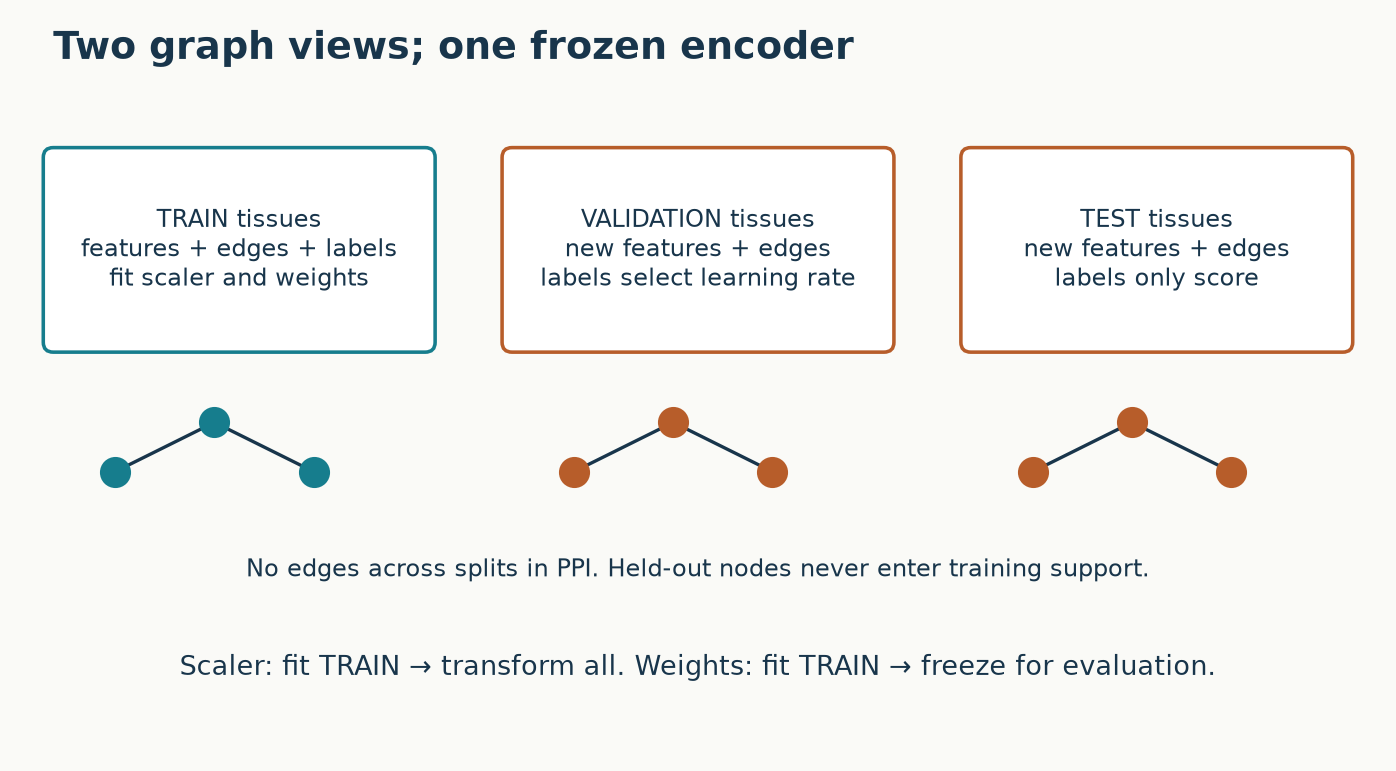</div><figcaption>Training sees only training tissues; fixed preprocessing and weights transfer to unseen graphs.</figcaption></figure>

Training uses only nodes and edges from training tissues. A loss mask is insufficient: held-out nodes must also be absent from the training neighbor table. Fit feature standardization on training rows, then reuse its mean and scale at validation and test time. These are two separate access rules. Masking labels cannot repair a scaler fitted on future data.

At inference we expose the query graph's features and edges, keep the learned weights fixed, and predict its labels. This is legitimate because those features and edges are assumed available at prediction time. PPI graphs are disjoint across splits; the loader's full inference table therefore does not create a training-to-test bridge. A future relational application must independently enforce time eligibility. An inductive split is not automatically a temporal split.

**Predict an intervention:** if we replace every held-out feature with 10,000 before training, should the fitted weights change? Under this contract they must not. Predictions on those changed nodes may change at inference. The lab checks the training invariance over a complete epoch, including optimizer updates. Its graph audit also verifies that no connected component crosses a split.

## 3 · The mean is simple; the paths must stay distinct

Paper Algorithm 1 aggregates neighbor states, combines that summary with the receiver's own state, applies shared weights and a nonlinearity, and normalizes the result. For a mean aggregator, the summary is

`m_v = (1 / |S(v)|) Σ_{u in S(v)} h_u`.

Neighbors form a multiset: the order should not matter, but repeated sampled IDs count repeatedly. Separate self information is valuable: “this node has a high value” differs from “its neighbors have a high average.” The paper's GCN-style alternative blends self and neighbors before transformation. That also differs from the symmetric augmented-degree weighting of lesson 82.

Our named executable target follows the **released mean implementation**, which computes

```python
m = neighbor_h.mean(dim=1)              # [B, S, d] -> [B, d]
self_branch = self_h @ W_self           # [B, d] @ [d, 128]
neighbor_branch = m @ W_neighbor        # [B, d] @ [d, 128]
h = torch.cat([self_branch, neighbor_branch], dim=-1)  # [B, 256]
```

This is not `cat([self, mean]) @ W` with an unrestricted mixing matrix and the same output width. It preserves two independently transformed blocks. A block-diagonal matrix could express this restricted operation; an arbitrary dense matrix additionally mixes the blocks. A common modern SAGE layer that **sums** two transforms is another variant. Names alone are not enough to identify a reproduction.

<figure class="mpnn-figure"><small>Scroll to inspect the full diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">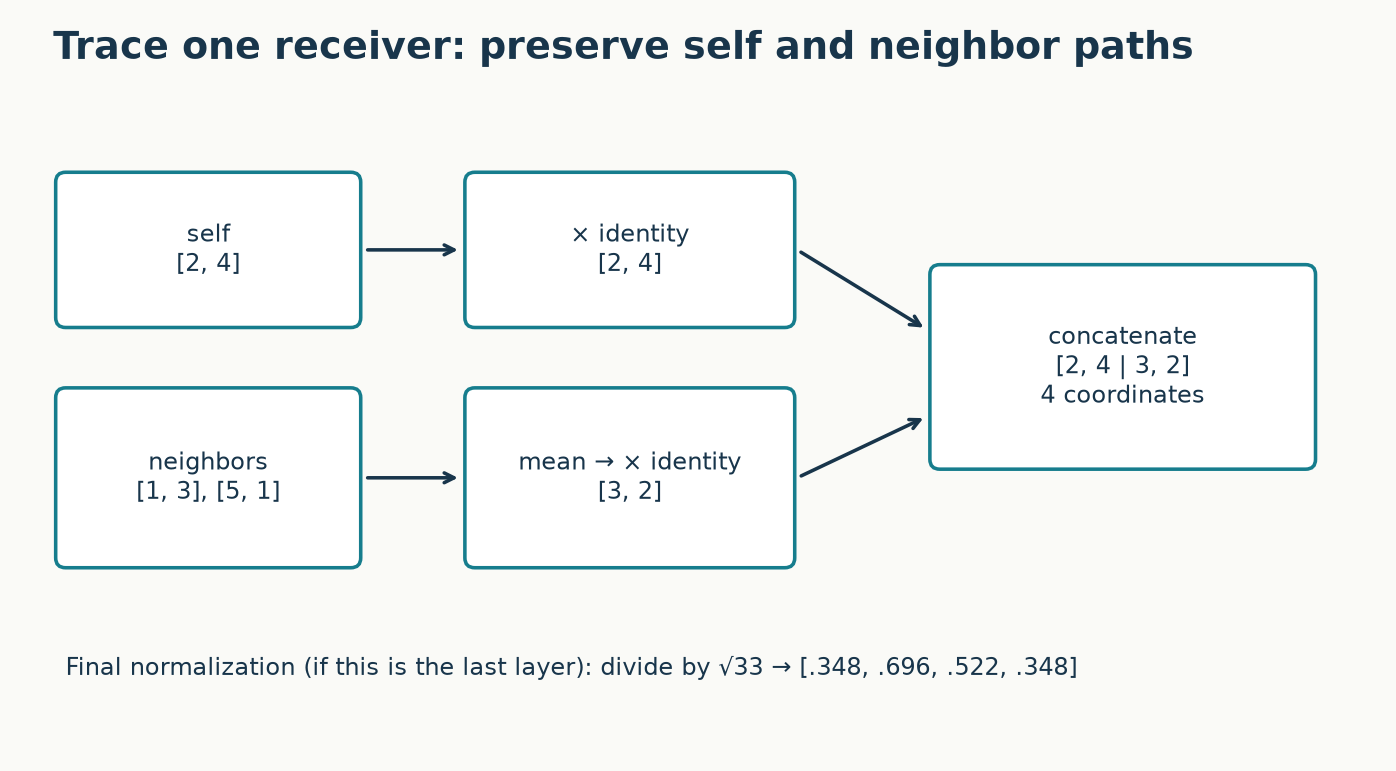</div><figcaption>Identity-weight illustration: distinct self and neighbor paths produce [2,4,3,2].</figcaption></figure>

In the illustrated case the receiver is `[2,4]`, neighbors are `[1,3]` and `[5,1]`, and both transforms are identity. The mean is `[3,2]`; the concatenated result is `[2,4,3,2]`. Its final unit-length version is approximately `[.3482,.6963,.5222,.3482]`, dividing by √33. This deliberately uses identity weights to make arithmetic visible; the trained network learns non-identity matrices. Replacing a neighbor changes only the neighbor branch at this layer, but later layers can mix earlier coordinates.

**Pause: write your prediction or teach-back before continuing.**

**Pause: write your prediction or teach-back before continuing.**

**Code versus pseudocode:** [released `models.py` and `supervised_models.py`](https://github.com/williamleif/GraphSAGE/tree/a0fdef95dca7b456dab01cb35034717c8b6dd017/graphsage) use ReLU after the first layer, identity activation after the last aggregator, and L2 normalization **once at the final embedding**. Algorithm 1 displays normalization within the recursion. This lab follows the release and states the discrepancy, rather than mixing the two silently.

## 4 · Sample outward, compute inward

A two-layer prediction needs first-hop states, which in turn need second-hop features. Start with a batch of root nodes, sample their neighbors, then sample neighbors of those neighbors. Only after collecting these dependencies can we aggregate from the outside inward. The two first-layer applications share the **same** weights: one computes root states, the other computes first-hop states. The second layer consumes those computed states.

<figure class="mpnn-figure"><small>Scroll to inspect the full diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">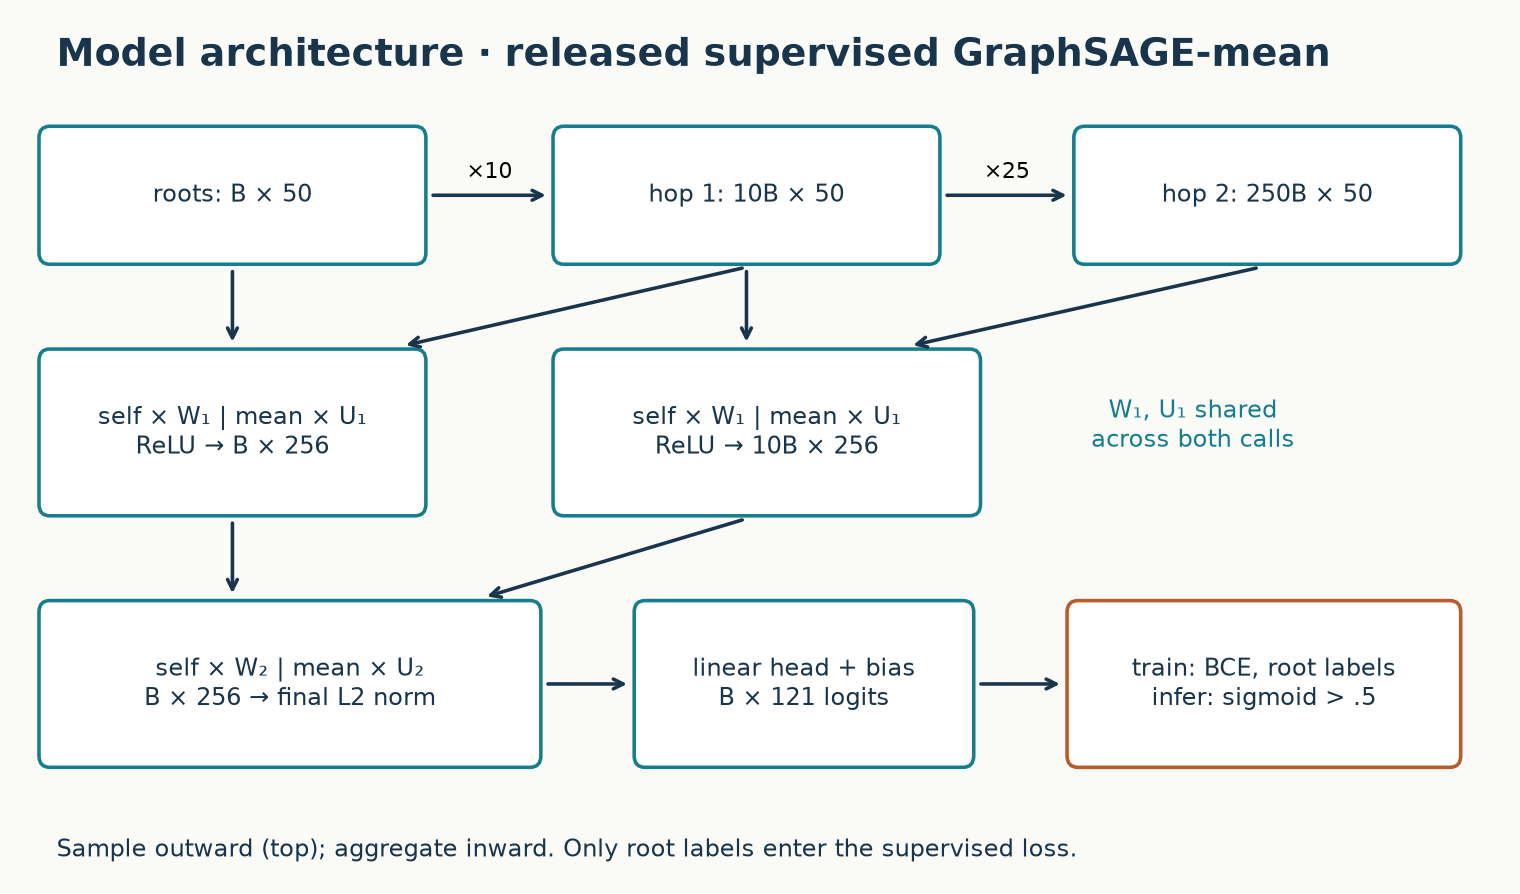</div><figcaption>Complete released mean encoder: outward support sampling and inward shared aggregation, normalization, head and objective.</figcaption></figure>

### Model architecture · complete supervised PPI path

The release flags say `samples_1=25`, `samples_2=10`. Its sampling loop reverses the layer list: from each root it collects **10 immediate neighbors, then 25 neighbors per immediate neighbor**. Our explicit outward fanouts are therefore `[10,25]`. For batch size 512, the materialized support has 512 roots, 5,120 first-hop occurrences, and 128,000 second-hop occurrences. These are occurrences, not necessarily unique node IDs. Repeated IDs and shared neighborhoods can reduce unique nodes without reducing this implementation's tensor sizes.

First-layer states have 256 coordinates (128 self + 128 neighbor). Second-layer states again have 256, followed by unit normalization and a biased `256→121` head. Binary cross-entropy is averaged over batch nodes **and** labels. The release default has no dropout and no weight decay. It initializes weights with Glorot uniform, uses Adam, and clips each gradient value to [-5,5]. That is elementwise clipping, not clipping the total gradient norm.

The root loss uses root labels only. Support nodes provide features; they do not become extra supervised examples simply because they appeared in a batch. Over an epoch they may separately appear as roots.

**Pause: write your prediction or teach-back before continuing.**

Sampling bounds the expansion, but it introduces variability and can miss rare informative neighbors. If a node has one decisive neighbor among 100, sampling 10 without replacement includes it with probability 0.1. The sampled mean is unbiased for the full mean under uniform sampling from the true list, but a nonlinear multilayer prediction generally is not an unbiased estimate of full-neighborhood prediction.

There is another approximation in the release: each adjacency row is capped or padded to 128 entries **once**, then minibatches sample its columns. High-degree neighbors excluded from this fixed table cannot appear later. Low-degree rows are filled by sampling with replacement; duplicates alter that table's empirical mean. We reproduce this table construction. At each hop the released sampler shuffles columns with one shared permutation across rows; the samples are not independent per row. These details can affect variance even when marginal sampling looks reasonable.

## 5 · Mean, pooling, LSTM: what information survives?

| Aggregator | Mechanism | What to test |
|---|---|---|
| Mean | Average neighbor vectors | `[0,2]` and `[1,1]` both average to 1 |
| Pooling | Shared learned transform of each neighbor, then coordinatewise max | A rare transformed feature can survive even when a mean dilutes it |
| LSTM | Process a randomized neighbor sequence | Reordering a sequence generally changes a single output |

Mean and max pooling are invariant to neighbor ordering. An LSTM is not inherently invariant; randomizing order during training is a procedure to cope with sets, not a proof of invariance. Pooling also discards multiplicity when max is unchanged. No aggregator universally preserves all multiset information. Later lessons on GIN will formalize this limitation.

The [paper's §3.3](https://arxiv.org/html/1706.02216v4) compares these designs. This lab implements and evaluates **mean only**. It does not infer a ranking among aggregators from our single model's result. The unsupervised variant uses a neighborhood-based contrastive objective; it is not the supervised multilabel objective used here.

## 6 · Reproduce the full named experiment, then assess the gap

Our target is **Table 1, supervised GraphSAGE-mean, PPI: micro-F1 = 0.598**. The paper uses 20 training tissue graphs, two validation graphs and two test graphs. Its appendix specifies ten epochs, batch size 512, width 256, and a supervised learning-rate sweep over .01, .001 and .0001. We run the full released archive, all ten epochs and all three rates. Test labels never select a rate or an epoch.

**Author reference, freshly executed:** 3 seeds × three learning rates × ten epochs on the full archive. Mean test micro-F1 **0.59093**, sample SD **0.00606**. This SD describes seed/search variation on the same split.

| Seed | Validation-selected learning rate | Test micro-F1 |
|---|---|---|
| 123 | 0.01 | 0.58528 |
| 124 | 0.01 | 0.59019 |
| 125 | 0.01 | 0.59733 |

[Full per-epoch traces and results](https://avistian.github.io/relational/labs/_paper_l083_results.json).

<figure class="mpnn-figure"><small>Scroll to inspect the full diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">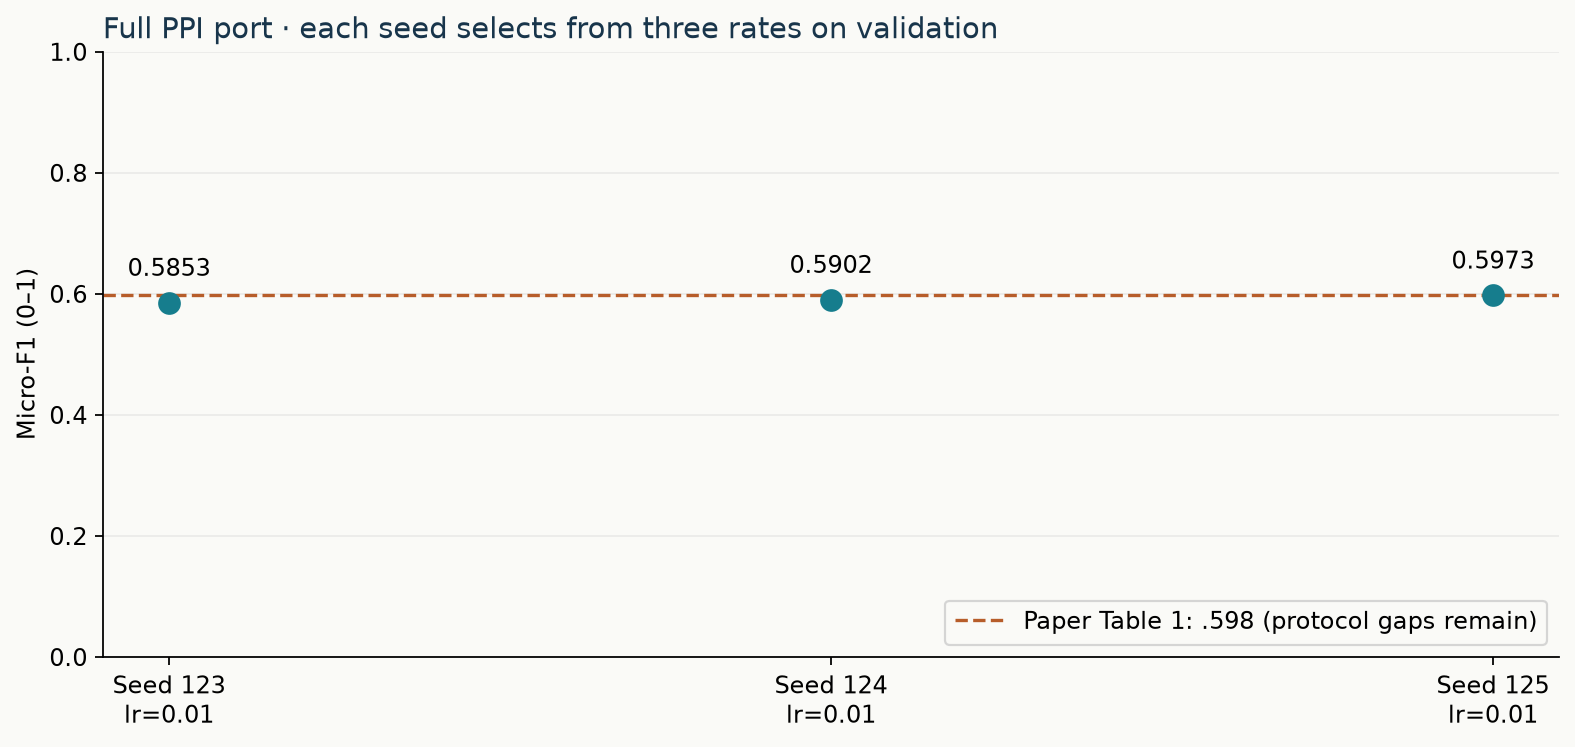</div><figcaption>Measured full-data ten-epoch ports; each seed runs three rates. The paper target is not a protocol-parity claim.</figcaption></figure>

The selection rule here chooses the learning rate with the largest full-validation micro-F1 after ten epochs. Ties keep the first listed rate. The test set is evaluated once for each selected model. Each seed repeats the full search; no seed is discarded. We report micro-F1 pooled over all node-label decisions, not an average of batch F1 scores. For multilabel data this is not ordinary accuracy.

Why can a full-size run still differ from the paper? The exact winning historical configuration, seed identities, replicate aggregation and complete selection recipe are not supplied with the table. The public code has implementation choices that differ from the pseudocode. Our modern PyTorch port changes RNG streams and numerical kernels; it uses sorted neighbor lists and independent deterministic evaluation RNG streams. The original TensorFlow run is **NOT_RUN**. The full reproduction contract audits each choice and the remaining uncertainty. A close metric would not erase these gaps, and an imperfect match is useful evidence to investigate rather than a reason to tune on test.

The status **INCOMPARABLE** means that historical result parity is not established; it does not mean the full PPI run was skipped. Training extent and protocol identity are separate questions. Our measurements support a reproducible port result on the released inductive split, not a claim about all graph tasks or all GraphSAGE variants.

## 7 · Lab: implement, intervene, explain

Open the [student notebook](https://avistian.github.io/relational/labs/0083-graphsage.ipynb), [readable preview](https://avistian.github.io/relational/labs/html/0083-graphsage.html), or [solution](https://avistian.github.io/relational/labs/solutions/0083-graphsage.ipynb). All model, sampling, preprocessing, selection and training code is inline. The notebook downloads the original archive and checks its SHA-256 before loading it; no hidden repository model is required.

1. **TODO / CHECK:** construct the induced training neighbor lists. Reject a held-out sender and a held-out receiver. Merely filtering the loss should fail this exercise.
2. **TODO / CHECK:** collect sampled supports in outward order. Check both the tensor sizes and actual IDs, including a zero-degree node's sentinel route.
3. **TODO / CHECK:** implement the separate self/neighbor transforms and concatenation. Check an independent hand result and neighbor reordering. These functions are called by the actual trainer.
4. Run the one-epoch teaching diagnostic. Then run the full experiment cell or the exact commands in the [reproduction contract](https://avistian.github.io/relational/labs/l083-reproduction.md). A one-epoch result has no paper-parity interpretation.
5. **EXIT:** submit the JSON result, your graph-access audit, and a paragraph explaining why “test labels hidden” was sufficient for L082's declared task but insufficient for this one. Include the output dimensions and outward fanout order, the selected rate, and one remaining historical reproduction gap.

Change a mean to a sum deliberately. Predict which check fails and why node degree now changes the scale. Restore it. After two days, reconstruct the three support tensors without looking at the code. After one week, explain the complete path from a newly arrived row to its predicted label, naming exactly which data were available during training.

**Pause: write your prediction or teach-back before continuing.**

## Where this leads

Mean aggregation gives every sampled neighbor equal weight. Lesson 84's planned GAT unit asks whether learned attention can distinguish neighbors before combining their messages. It must still answer our access and sampling questions; attention does not excuse leakage. For now, use the [reference card](https://avistian.github.io/relational/reference/0083-graphsage.html) and read **§3, Algorithm 2 and Appendix C** of the [primary paper](https://arxiv.org/html/1706.02216v4). Ask the agent follow-up questions about any tensor shape, sampling decision or mismatch you cannot explain from memory.


## Source attribution

Adapted from William L. Hamilton and Rex Ying, GraphSAGE (MIT), pinned revision a0fdef95dca7b456dab01cb35034717c8b6dd017. Full license:

```text
The MIT License

Copyright (c) 2017 William L. Hamilton, Rex Ying

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.

Portions of this code base were orginally forked from: https://github.com/tkipf/gcn, which is under the following License:

Copyright (c) 2016 Thomas Kipf

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.

```

In [ ]:
import copy

In [ ]:
import hashlib

In [ ]:
import json

In [ ]:
import time

In [ ]:
import urllib.request

In [ ]:
import zipfile

In [ ]:
from pathlib import Path

In [ ]:
import numpy as np

In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
from torch.nn import functional as F

In [ ]:
from sklearn.preprocessing import StandardScaler

### PROVIDED · load_ppi

Verify the complete Stanford archive before reading arrays; fit scaling on training nodes.

In [ ]:
def load_ppi(root, manifest):
    """Verify the complete Stanford archive before reading arrays; fit scaling on training nodes."""
    root = Path(root); root.mkdir(parents=True, exist_ok=True)
    archive = root / 'ppi.zip'
    if not archive.exists():
        urllib.request.urlretrieve(manifest['data']['url'], archive)
    assert hashlib.sha256(archive.read_bytes()).hexdigest() == manifest['data']['sha256'], 'PPI bytes differ'
    with zipfile.ZipFile(archive) as z:
        def member(suffix):
            matches = [n for n in z.namelist() if n.endswith(suffix)]
            assert len(matches) == 1, matches
            return z.open(matches[0])
        graph = json.load(member('-G.json'))
        ids = {int(k): int(v) for k, v in json.load(member('-id_map.json')).items()}
        labels = json.load(member('-class_map.json'))
        x = np.load(member('-feats.npy'), allow_pickle=False)
    nodes = [v for v in graph['nodes'] if 'val' in v and 'test' in v]
    n = len(ids); assert x.shape[0] == n
    masks = {key: np.zeros(n, dtype=bool) for key in ['train','valid','test']}
    y = np.zeros((n, len(next(iter(labels.values())))), dtype=np.float32)
    for v in nodes:
        i = ids[int(v['id'])]
        assert not (v['val'] and v['test'])
        masks['valid'][i] = v['val']; masks['test'][i] = v['test']
        masks['train'][i] = not (v['val'] or v['test'])
        y[i] = labels[str(v['id'])]
    # Legacy node-link JSON endpoints index graph['nodes'], rather than feature rows.
    adj = [set() for _ in range(n)]
    active = {int(v['id']) for v in nodes}
    for e in graph['links']:
        u = int(graph['nodes'][e['source']]['id']); v = int(graph['nodes'][e['target']]['id'])
        if u in active and v in active:
            a,b = ids[u],ids[v]; adj[a].add(b); adj[b].add(a)
    scaler = StandardScaler().fit(x[masks['train']])
    x = scaler.transform(x).astype(np.float32)
    # A zero sentinel is the released convention for empty neighbor lists.
    x = torch.from_numpy(np.vstack([x,np.zeros((1,x.shape[1]),dtype=np.float32)]))
    return {'x':x, 'y':torch.from_numpy(y), 'adj':[np.array(sorted(a),dtype=np.int64) for a in adj],
            'masks':masks, 'scaler_mean':scaler.mean_.tolist()}

### TODO · eligible_neighbors

TODO: induced training graph. Both receiver and sender must be eligible.

In [ ]:
def eligible_neighbors(adj, train_mask):
    raise NotImplementedError("Implement eligible_neighbors from the contract and pass the CHECK")

In [ ]:
adj=[np.array([1,2]),np.array([0]),np.array([0])]
mask=np.array([True,True,False])
assert [a.tolist() for a in eligible_neighbors(adj,mask)]==[[1],[0],[]], 'Filter both receiver and sender'
print('CHECK: held-out nodes cannot enter either side of a training edge')

### PROVIDED · padded_adjacency

Release minibatch.py: cap long rows without replacement; resample short rows with replacement.

In [ ]:
def padded_adjacency(adj, max_degree, rng):
    """Release minibatch.py: cap long rows without replacement; resample short rows with replacement."""
    n = len(adj); table = np.full((n+1,max_degree),n,dtype=np.int64)
    for i, row in enumerate(adj):
        if len(row):
            table[i] = rng.choice(row,max_degree,replace=len(row)<max_degree) if len(row)!=max_degree else row
    return torch.from_numpy(table)

### TODO · sample_support

TODO: expand roots outward; one shared shuffled column order per hop matches the release.

In [ ]:
def sample_support(roots, table, fanouts, generator):
    raise NotImplementedError("Implement sample_support from the contract and pass the CHECK")

In [ ]:
table=torch.tensor([[1,1,1,1],[0,0,0,0],[3,3,3,3],[3,3,3,3]])
s=sample_support(torch.tensor([0,2]),table,[2,3],torch.Generator().manual_seed(0))
assert [len(v) for v in s]==[2,4,12]
assert s[1].tolist()==[1,1,3,3] and s[2].tolist()==[0]*6+[3]*6
print('CHECK: outward expansion, node IDs, zero sentinel')

### TODO · mean_concat

TODO: release MeanAggregator(concat=True), before activation; neighbors have shape [B,S,d].

In [ ]:
def mean_concat(self_h, neighbor_h, w_self, w_neighbor):
    raise NotImplementedError("Implement mean_concat from the contract and pass the CHECK")

In [ ]:
h=torch.tensor([[2.,4.]])
n=torch.tensor([[[1.,3.],[5.,1.]]]);w=torch.eye(2)
z=mean_concat(h,n,w,w)
torch.testing.assert_close(z,torch.tensor([[2.,4.,3.,2.]]))
torch.testing.assert_close(mean_concat(h,n.flip(1),w,w),z)
print('CHECK: separate branches and permutation invariance')

### PROVIDED · MeanLayer

Two distinct learned transforms; concatenation doubles the branch width.

In [ ]:
class MeanLayer(nn.Module):
    """Two distinct learned transforms; concatenation doubles the branch width."""
    def __init__(self, input_dim, branch_dim=128):
        super().__init__()
        self.w_self = nn.Parameter(torch.empty(input_dim,branch_dim))
        self.w_neighbor = nn.Parameter(torch.empty(input_dim,branch_dim))
        nn.init.xavier_uniform_(self.w_self); nn.init.xavier_uniform_(self.w_neighbor)
    def forward(self, h, neighbors):
        return mean_concat(h,neighbors,self.w_self,self.w_neighbor)

### PROVIDED · GraphSAGE

Full two-layer released mean encoder + final L2 normalization + multilabel linear head.

In [ ]:
class GraphSAGE(nn.Module):
    """Full two-layer released mean encoder + final L2 normalization + multilabel linear head."""
    def __init__(self, input_dim, classes, branch_dim=128):
        super().__init__()
        self.layers = nn.ModuleList([MeanLayer(input_dim,branch_dim),MeanLayer(2*branch_dim,branch_dim)])
        self.head = nn.Linear(2*branch_dim,classes)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self, x, samples, fanouts=(10,25)):
        hidden = [x[s] for s in samples]
        for layer_index,layer in enumerate(self.layers):
            new_hidden = []
            for hop in range(len(hidden)-1):
                neighbors = hidden[hop+1].reshape(len(hidden[hop]),fanouts[hop],-1)
                h = layer(hidden[hop],neighbors)
                new_hidden.append(F.relu(h) if layer_index == 0 else h)
            hidden = new_hidden
        # TF l2_normalize uses sqrt(max(sum(x*x),epsilon)), with epsilon=1e-12.
        h = hidden[0] / hidden[0].square().sum(-1,keepdim=True).clamp_min(1e-12).sqrt()
        return self.head(h)

### PROVIDED · micro_f1

Pool label decisions across nodes/classes. Logit >0 equals sigmoid >0.5.

In [ ]:
def micro_f1(logits, labels):
    """Pool label decisions across nodes/classes. Logit >0 equals sigmoid >0.5."""
    pred = logits > 0; true = labels.bool()
    tp = (pred & true).sum().item(); fp=(pred & ~true).sum().item(); fn=(~pred & true).sum().item()
    return 2*tp/max(2*tp+fp+fn,1)

### PROVIDED · evaluate

Inference uses held-out features/edges, never fitting or adapting weights.

In [ ]:
def evaluate(model, data, table, nodes, fanouts, batch_size, seed):
    """Inference uses held-out features/edges, never fitting or adapting weights."""
    gen=torch.Generator().manual_seed(seed); model.eval(); out=[]
    with torch.no_grad():
        for start in range(0,len(nodes),batch_size):
            roots=torch.as_tensor(nodes[start:start+batch_size])
            out.append(model(data['x'],sample_support(roots,table,fanouts,gen),fanouts))
    logits=torch.cat(out); labels=data['y'][nodes]
    return {'micro_f1':micro_f1(logits,labels),'loss':float(F.binary_cross_entropy_with_logits(logits,labels))}

### PROVIDED · fit_candidate

Full schedule; no best-epoch selection. Validation selects only the learning rate.

In [ ]:
def fit_candidate(data, seed, learning_rate, config, tables=None):
    """Full schedule; no best-epoch selection. Validation selects only the learning rate."""
    torch.manual_seed(seed); rng=np.random.RandomState(seed)
    induced=eligible_neighbors(data['adj'],data['masks']['train'])
    if tables is None:
        tables=(padded_adjacency(induced,config['max_degree'],rng),padded_adjacency(data['adj'],config['max_degree'],rng))
    train_table,inference_table=tables
    roots=np.array([i for i in np.flatnonzero(data['masks']['train']) if len(induced[i])],dtype=np.int64)
    model=GraphSAGE(data['x'].shape[1],data['y'].shape[1],config['branch_dim'])
    opt=torch.optim.Adam(model.parameters(),lr=learning_rate,eps=1e-8)
    gen=torch.Generator().manual_seed(seed+1000); trace=[]; started=time.time()
    for epoch in range(config['epochs']):
        order=rng.permutation(roots); total=0.; count=0; model.train()
        for start in range(0,len(order),config['batch_size']):
            batch=torch.from_numpy(order[start:start+config['batch_size']])
            samples=sample_support(batch,train_table,config['fanouts'],gen)
            logits=model(data['x'],samples,config['fanouts'])
            loss=F.binary_cross_entropy_with_logits(logits,data['y'][batch])
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_value_(model.parameters(),5.); opt.step()
            total+=float(loss.detach())*len(batch);count+=len(batch)
        trace.append({'epoch':epoch+1,'train_loss':total/count})
    valid=evaluate(model,data,inference_table,np.flatnonzero(data['masks']['valid']),config['fanouts'],config['batch_size'],seed+2000)
    return model,{'lr':learning_rate,'validation':valid,'trace':trace,'seconds':time.time()-started},inference_table

### PROVIDED · experiment

Three-rate validation sweep, final-weight evaluation, frozen test once per selected model.

In [ ]:
def experiment(data, seeds, config, output=None):
    """Three-rate validation sweep, final-weight evaluation, frozen test once per selected model."""
    result={'scope':'full PPI release-protocol port' if config['epochs']==10 and config['branch_dim']==128 else 'teaching run',
            'paper_target':.598,'status':'INCOMPARABLE','config':config,'runs':[],
            'versions':{'torch':torch.__version__,'numpy':np.__version__},
            'data_shape':list(data['x'].shape),'split_sizes':{k:int(v.sum()) for k,v in data['masks'].items()}}
    for seed in seeds:
        candidates=[]; best=None
        for lr in config['learning_rates']:
            model,record,table=fit_candidate(data,seed,lr,config)
            candidates.append(record)
            if best is None or record['validation']['micro_f1']>best[0]:
                best=(record['validation']['micro_f1'],copy.deepcopy(model.state_dict()),lr,table)
            print(f'seed={seed} lr={lr} validation={record["validation"]["micro_f1"]:.4f}',flush=True)
        model.load_state_dict(best[1])
        test=evaluate(model,data,best[3],np.flatnonzero(data['masks']['test']),config['fanouts'],config['batch_size'],seed+3000)
        result['runs'].append({'seed':seed,'candidates':candidates,'selected_lr':best[2],'test':test})
        scores=[r['test']['micro_f1'] for r in result['runs']]
        result['mean']=float(np.mean(scores));result['sample_sd']=float(np.std(scores,ddof=1)) if len(scores)>1 else None
        if output:Path(output).write_text(json.dumps(result,indent=2)+'\n')
    return result

In [ ]:
PAPER_CONFIG={'epochs':10,'branch_dim':128,'batch_size':512,'max_degree':128,'fanouts':[10,25],'learning_rates':[.01,.001,.0001]}

## PROVIDED · immutable data identity

The archive downloads from Stanford only if absent; its SHA-256 is verified before loading. StandardScaler fits only training rows.

In [ ]:
manifest={'repository': 'https://github.com/williamleif/GraphSAGE', 'revision': 'a0fdef95dca7b456dab01cb35034717c8b6dd017', 'data': {'url': 'https://snap.stanford.edu/graphsage/ppi.zip', 'sha256': '53aeb76e54fd41b645e7edb48b62929240b89839495396b048086fd212503fbd'}, 'files': {'LICENSE.txt': 'e7b56d979cbc061584023360914ab1753f84366eb72f802f4b3ce2af0c4af187', 'example_supervised.sh': '9436482c96c18b47c9fa8dfc5398478ef659d492d7b189ef71b7bfb19a8749ee', 'requirements.txt': '85f410161e519d1eeed6209d89e2457ba7773e9d521fd9aafac77f73baf019b1', 'README.md': 'dbd59cd1ee4454103e3cd5911ac39b6dfebcde557dd1ff70cc52b482f9c5a536', 'graphsage/utils.py': 'f1a6dd0b509c386330226f1820ad512680d6230163fa2e5a41cf26a5c8d6fa55', 'graphsage/models.py': '866c742c8747cfb1f9d7f5ea050590dd6cbf5c3c8a2138fa7454101821ee5fd0', 'graphsage/neigh_samplers.py': '7b7ccf73c8d4b6cf44aed7d836138d897517089ddaf041bf44ca45e9a80d7af8', 'graphsage/supervised_models.py': 'e81df7f3d523e7994408e63bf346e89fefbe6d8b96babfcc1cd8cbc1f4d41fba', 'graphsage/layers.py': '76f7c6299c7743457fdf628c3348a8f177b3a9f47c516999a3ed5082f703338e', 'graphsage/minibatch.py': '087f80e83f9a354fc92f89518059ebeade4e4723b7ca34be46c6edb02b1e7b89', 'graphsage/inits.py': '440367e3890eee3946a759a43e1f28b236c777e351509d8334bfac100938edda', 'graphsage/supervised_train.py': 'a4dd08f483ecdf028e4a965c45641d365a7e3eec02de92e44a1e8f51abe89228', 'graphsage/aggregators.py': '6349d0b00c89829aa10ddbe0ae03e7ebdd00fdc70e652e03938f3caf9036349f'}}
torch.set_num_threads(1)
data=load_ppi(Path.cwd()/'data/l083',manifest)
assert data['x'].shape==(56945,50) and data['y'].shape==(56944,121)
print({k:int(v.sum()) for k,v in data['masks'].items()})

## Teaching run · one full-data epoch, smaller width

Check that the implemented functions train. This is explicitly not the paper schedule.

In [ ]:
teaching_config=dict(PAPER_CONFIG,epochs=1,branch_dim=16,learning_rates=[.01])
teaching=experiment(data,[123],teaching_config)
print('TEACHING ONLY',teaching['mean'])

## Full named experiment · three seeds × three rates × ten epochs

CPU is sufficient; author runs use one thread to avoid oversubscription. All data, full dimensions and full schedule. This is a modern release port with documented historical gaps. Read the contract before interpreting proximity to .598.

In [ ]:
RUN_FULL_REPRO = True
if RUN_FULL_REPRO:
    result=experiment(data,[123,124,125],copy.deepcopy(PAPER_CONFIG),'l083-student-results.json')
    print('Full PPI port mean / sample SD:',result['mean'],result['sample_sd'])

## EXIT TICKET

Attach your full result JSON. Explain the split-access invariant, fanout reversal, dimensions, code-versus-pseudocode differences, and a remaining historical gap. Change a mean to a sum; predict and capture the failing CHECK, then restore it. Do not infer mastery from executing the solution.

In [ ]:
artifact={'lesson':83,'source_revision':manifest['revision'],'full_run':RUN_FULL_REPRO,'paper_target':.598,'historical_parity':'INCOMPARABLE','explanation':'ADD YOUR OWN MARKDOWN EXPLANATION'}
if RUN_FULL_REPRO:artifact.update(mean=result['mean'],sample_sd=result['sample_sd'])
Path('l083-exit.json').write_text(json.dumps(artifact,indent=2))
print(artifact)